# Ejercicio 1. Modelo de un experimento con una red neuronal de dos capas ocultas

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 1: *Tome una tabla de datos de un experimento cualquiera. Encuentre un modelo con base en una red neuronal de dos capas ocultas. Dele datos a ese modelo para hacer una predicción.*

---

## 1. El experimento

Se toma la tabla de datos del experimento de **cinética enzimática con puromicina** de Treloar (1974), un conjunto clásico de laboratorio publicado en el libro de Bates y Watts, *Nonlinear Regression Analysis and Its Applications* (1988), y distribuido con el lenguaje R como `Puromycin`.

En el experimento se midió la **velocidad inicial de una reacción enzimática** (en cuentas/min², a partir de la radiactividad del producto) para distintas **concentraciones del sustrato** (en ppm). El ensayo se hizo con dos grupos de células: unas **tratadas** con el antibiótico puromicina y otras **sin tratar**. Cada concentración se midió dos veces, salvo la mayor en las células sin tratar, que tiene una sola medición, así que la tabla tiene 23 filas.

El objetivo del modelo es **predecir la velocidad de la reacción** a partir de dos características:

| Símbolo | Variable | Tipo |
|---|---|---|
| $x_1$ | concentración del sustrato (ppm) | numérica, de 0.02 a 1.10 |
| $x_2$ | estado de las células (1 = tratadas, 0 = sin tratar) | binaria |
| $Y$ | velocidad de la reacción (cuentas/min²) | numérica: es el **rótulo** |

Es un problema de **predicción** (regresión) en el sentido de la sección 5.3 del capítulo: la salida es un número, no una clase.

El experimento se escogió por tres razones. Es una tabla real de laboratorio, pequeña y completa, que cabe en el propio notebook. La relación entre las variables **no es lineal**: la velocidad crece rápido a bajas concentraciones y luego se satura. Y existe un **modelo físico conocido** para este tipo de reacción, la ecuación de Michaelis-Menten, que sirve como referencia independiente para juzgar lo que aprenda la red.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.width", 120)

## 2. La tabla de datos

In [2]:
tabla = pd.DataFrame({
    "concentracion": [0.02, 0.02, 0.06, 0.06, 0.11, 0.11, 0.22, 0.22, 0.56, 0.56, 1.10, 1.10,
                      0.02, 0.02, 0.06, 0.06, 0.11, 0.11, 0.22, 0.22, 0.56, 0.56, 1.10],
    "velocidad":     [76, 47, 97, 107, 123, 139, 159, 152, 191, 201, 207, 200,
                      67, 51, 84, 86, 98, 115, 131, 124, 144, 158, 160],
    "estado":        ["tratadas"] * 12 + ["sin tratar"] * 11,
})
tabla["tratada"] = (tabla["estado"] == "tratadas").astype(int)
print(f"{len(tabla)} mediciones: {tabla.tratada.sum()} con celulas tratadas y {(1 - tabla.tratada).sum()} sin tratar\n")
print(tabla.pivot_table(index="concentracion", columns="estado", values="velocidad",
                        aggfunc=lambda v: ", ".join(str(int(x)) for x in v)).to_string())

23 mediciones: 12 con celulas tratadas y 11 sin tratar

estado        sin tratar  tratadas
concentracion                     
0.02              67, 51    76, 47
0.06              84, 86   97, 107
0.11             98, 115  123, 139
0.22            131, 124  159, 152
0.56            144, 158  191, 201
1.10                 160  207, 200


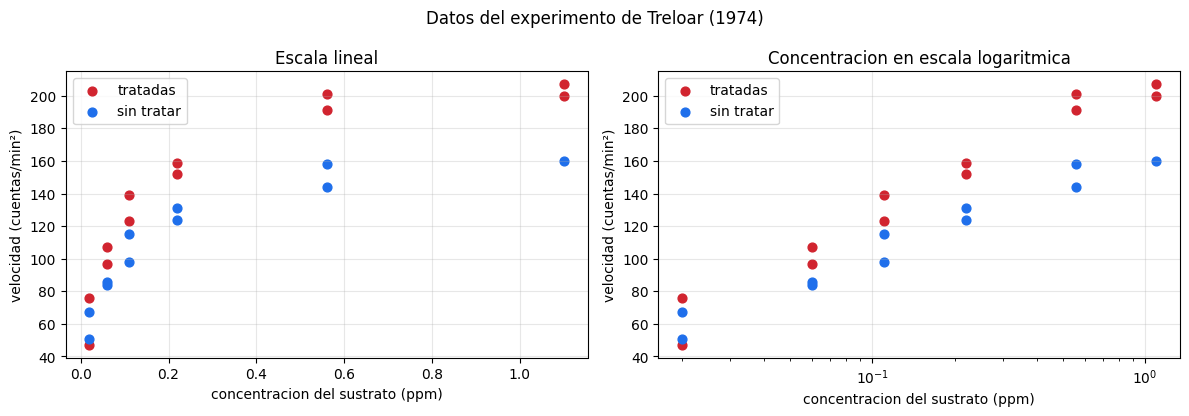

In [3]:
COLOR = {1: "#d1242f", 0: "#1f6feb"}
ETIQ = {1: "tratadas", 0: "sin tratar"}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for s in (1, 0):
    d = tabla[tabla.tratada == s]
    ax[0].scatter(d.concentracion, d.velocidad, color=COLOR[s], label=ETIQ[s], s=40)
    ax[1].scatter(d.concentracion, d.velocidad, color=COLOR[s], label=ETIQ[s], s=40)
ax[0].set_title("Escala lineal"); ax[1].set_title("Concentracion en escala logaritmica")
ax[1].set_xscale("log")
for a in ax:
    a.set_xlabel("concentracion del sustrato (ppm)"); a.set_ylabel("velocidad (cuentas/min²)"); a.legend()
plt.suptitle("Datos del experimento de Treloar (1974)")
plt.tight_layout(); plt.show()

Las dos gráficas muestran el comportamiento típico de una reacción catalizada por una enzima. A bajas concentraciones la velocidad crece rápidamente, porque hay enzima libre de sobra; a altas concentraciones la enzima está casi toda ocupada y la velocidad se acerca a un máximo. Las células tratadas alcanzan velocidades mayores que las no tratadas en todo el rango. Se observa además que las dos repeticiones de una misma condición pueden diferir bastante (76 y 47 en la primera fila de las tratadas): es el **ruido experimental**, y ningún modelo podrá predecir una medición nueva con un error menor que esa variabilidad.

## 3. Diseño de la red

### 3.1 Preparación de las características

Se usan dos características, siguiendo la notación del capítulo, $X = [x_1,\ x_2]^T$:

- $x_1 = $ **logaritmo de la concentración, estandarizado**. Las concentraciones van de 0.02 a 1.10, un factor de 55, y están espaciadas aproximadamente en progresión geométrica (0.02, 0.06, 0.11, 0.22, 0.56, 1.10). En escala logarítmica los puntos quedan repartidos de forma pareja y la curva es más suave, como se ve en la gráfica de la derecha. Después se resta la media y se divide por la desviación estándar, para que la entrada quede en la zona en la que la sigmoide no está saturada.
- $x_2 = $ **estado de las células**: 1 si están tratadas y 0 si no.

El rótulo $Y$, la velocidad, también se estandariza. Así los pesos iniciales entre −1 y 1 producen salidas del mismo orden de magnitud que los rótulos, y la pérdida inicial no es enorme. Las predicciones se devuelven a cuentas/min² con la transformación inversa.

In [4]:
lc = np.log10(tabla.concentracion.values)
MEDIA_LC, DESV_LC = lc.mean(), lc.std()
MEDIA_Y, DESV_Y = tabla.velocidad.values.mean(), tabla.velocidad.values.std()

def caracteristicas(concentracion, tratada):
    "Construye la matriz X (2 x m): columnas = ejemplos, filas = caracteristicas."
    c = np.atleast_1d(np.asarray(concentracion, dtype=float))
    t = np.broadcast_to(np.asarray(tratada, dtype=float), c.shape)
    return np.vstack([(np.log10(c) - MEDIA_LC) / DESV_LC, t])

def a_velocidad(y_escalada):
    "Convierte la salida de la red a cuentas/min²."
    return y_escalada * DESV_Y + MEDIA_Y

X = caracteristicas(tabla.concentracion, tabla.tratada)
Yr = ((tabla.velocidad.values - MEDIA_Y) / DESV_Y).reshape(1, -1)
print("X:", X.shape, "  Yr:", Yr.shape)
print(f"log10(concentracion): media {MEDIA_LC:.4f}, desviacion {DESV_LC:.4f}")
print(f"velocidad: media {MEDIA_Y:.4f}, desviacion {DESV_Y:.4f}")
print("\nPrimeras tres columnas de X:\n", X[:, :3])

X: (2, 23)   Yr: (1, 23)
log10(concentracion): media -0.8274, desviacion 0.5685
velocidad: media 126.8261, desviacion 46.4689

Primeras tres columnas de X:
 [[-1.532903 -1.532903 -0.693713]
 [ 1.        1.        1.      ]]


### 3.2 Topología: dos capas ocultas

La red tiene la misma estructura que la figura 5.13 del capítulo: una capa de entrada, **dos capas ocultas** y una capa de salida.

| Capa | Neuronas | Activación | Qué calcula |
|---|:-:|---|---|
| 0, entrada | 2 | — | $A^{(0)} = X$ |
| 1, **primera capa oculta** | 4 | sigmoide | $Z^{(1)} = W^{(1)}A^{(0)} + B^{(1)}$, $\ A^{(1)} = \sigma(Z^{(1)})$ |
| 2, **segunda capa oculta** | 4 | sigmoide | $Z^{(2)} = W^{(2)}A^{(1)} + B^{(2)}$, $\ A^{(2)} = \sigma(Z^{(2)})$ |
| 3, salida | 1 | lineal | $Z^{(3)} = W^{(3)}A^{(2)} + B^{(3)}$, $\ H_w(X) = A^{(3)} = Z^{(3)}$ |

Esta red se denota 2‑4‑4‑1. La única diferencia con las redes del capítulo está en la neurona de salida, que es **lineal** ($g(z) = z$) en lugar de sigmoide. La sigmoide solo produce valores entre 0 y 1, apropiados para una clase, pero aquí la salida es una velocidad que puede tomar cualquier valor. Las neuronas de las dos capas ocultas conservan la sigmoide, que es la que introduce la no linealidad.

**Retropropagación.** Se usan las ecuaciones de la sección 5.5 del capítulo para una red de tres capas, con la función de pérdida $J(W) = \frac{1}{2m}\sum (h_w(X) - Y)^2$, que promedia el error cuadrático sobre los $m = 23$ ejemplos:

$$e = Y_r - A^{(3)},\qquad \delta^{(3)} = \tfrac{1}{m}\,e$$
$$\delta^{(2)} = \mathrm{diag}\big(\sigma'(Z^{(2)})\big)\,W^{(3)T}\delta^{(3)},\qquad \delta^{(1)} = \mathrm{diag}\big(\sigma'(Z^{(1)})\big)\,W^{(2)T}\delta^{(2)}$$
$$\frac{\partial J}{\partial W^{(k)}} = -\delta^{(k)}A^{(k-1)T},\qquad \frac{\partial J}{\partial B^{(k)}} = -\delta^{(k)},\qquad W^{(k)} \leftarrow W^{(k)} - \eta\,\frac{\partial J}{\partial W^{(k)}}$$

Como la salida es lineal, su derivada vale 1 y el factor $\mathrm{diag}(\sigma'(Z^{(3)}))$ de la capa de salida se reemplaza por la identidad. La derivada de la sigmoide es $\sigma'(z) = \sigma(z)(1-\sigma(z))$, la expresión de la sección 5.2.2. Los 23 ejemplos se procesan a la vez: $X$ es una matriz de $2\times23$ cuyas columnas son los ejemplos, el producto $\delta^{(k)}A^{(k-1)T}$ suma automáticamente las contribuciones de todos ellos y la matriz diagonal se aplica como un producto elemento a elemento, que es equivalente.

In [5]:
NN = [2, 4, 4, 1]          # entradas, oculta 1, oculta 2, salida

def sig(s):
    "Funcion de activacion sigmoide."
    return 1 / (1 + np.exp(-s))

def dSig(s):
    "Derivada de la sigmoide: sigma'(z) = sigma(z) (1 - sigma(z))."
    return sig(s) * (1 - sig(s))

def inicializa(nn, semilla):
    "Pesos y sesgos aleatorios uniformes en [-1, 1]. W[k] tiene forma (neuronas capa k, neuronas capa k-1)."
    rng = np.random.default_rng(semilla)
    W = [None] + [rng.uniform(-1, 1, (nn[k], nn[k - 1])) for k in (1, 2, 3)]
    B = [None] + [rng.uniform(-1, 1, (nn[k], 1)) for k in (1, 2, 3)]
    return W, B

def propaga(X, W, B):
    "Propagacion hacia adelante por las dos capas ocultas y la capa de salida."
    Z1 = W[1] @ X  + B[1];  A1 = sig(Z1)       # capa oculta 1
    Z2 = W[2] @ A1 + B[2];  A2 = sig(Z2)       # capa oculta 2
    Z3 = W[3] @ A2 + B[3];  A3 = Z3            # capa de salida, activacion lineal
    return A3, (Z1, A1, Z2, A2, Z3)

def perdida(A3, Yr):
    "J(W) = 1/(2m) * suma de (h_w(X) - Y)^2, seccion 5.5."
    m = Yr.shape[1]
    return np.sum((A3 - Yr) ** 2) / (2 * m)

def backpropagation(X, Yr, W, B):
    "Gradientes de J respecto a cada W y B, con los deltas de la seccion 5.5."
    m = X.shape[1]
    A3, (Z1, A1, Z2, A2, Z3) = propaga(X, W, B)
    e = Yr - A3                                  # error de la red
    delta3 = e / m                               # salida lineal: sigma'(Z3) se reemplaza por 1
    delta2 = dSig(Z2) * (W[3].T @ delta3)        # delta2 = diag(sigma'(Z2)) W3^T delta3
    delta1 = dSig(Z1) * (W[2].T @ delta2)        # delta1 = diag(sigma'(Z1)) W2^T delta2
    dW = [None, -delta1 @ X.T, -delta2 @ A1.T, -delta3 @ A2.T]
    dB = [None, -delta1.sum(axis=1, keepdims=True), -delta2.sum(axis=1, keepdims=True),
          -delta3.sum(axis=1, keepdims=True)]
    return dW, dB

def entrena(X, Yr, nn, eta, epocas, semilla):
    "Descenso del gradiente con todos los ejemplos en cada epoca."
    W, B = inicializa(nn, semilla)
    historia = []
    for _ in range(epocas):
        dW, dB = backpropagation(X, Yr, W, B)
        for k in (1, 2, 3):
            W[k] = W[k] - eta * dW[k]
            B[k] = B[k] - eta * dB[k]
        historia.append(perdida(propaga(X, W, B)[0], Yr))
    return W, B, np.array(historia)

W0, B0 = inicializa(NN, semilla=1)
n_param = sum(W0[k].size + B0[k].size for k in (1, 2, 3))
for k in (1, 2, 3):
    print(f"Capa {k}: W{k} {W0[k].shape}  B{k} {B0[k].shape}  -> {W0[k].size + B0[k].size} parametros")
print("Total de parametros:", n_param)

Capa 1: W1 (4, 2)  B1 (4, 1)  -> 12 parametros
Capa 2: W2 (4, 4)  B2 (4, 1)  -> 20 parametros
Capa 3: W3 (1, 4)  B3 (1, 1)  -> 5 parametros
Total de parametros: 37


El programa conserva los nombres de las funciones del programa del Ejemplo 1 del capítulo (`sig`, `dSig`, `propaga`, `backpropagation`), extendidos a dos capas ocultas. La red tiene 37 parámetros: $2\cdot4+4 = 12$ en la primera capa oculta, $4\cdot4+4 = 20$ en la segunda y $4+1 = 5$ en la salida.

Son más parámetros que datos (37 frente a 23), así que la red tiene capacidad para memorizar la tabla, incluido el ruido. Por eso el número de épocas no se fija a ojo sino con validación cruzada (sección 5), y la red se compara con modelos más simples (sección 7).

## 4. Verificación del gradiente

Antes de entrenar se comprueba que `backpropagation` calcula bien las 37 derivadas. Cada parámetro se mueve una cantidad $\pm h$ y se mide el cambio en la pérdida:

$$\frac{\partial J}{\partial w} \approx \frac{J(w+h) - J(w-h)}{2h}$$

In [6]:
def gradiente_numerico(X, Yr, W, B, h=1e-6):
    gW = [None] + [np.zeros_like(W[k]) for k in (1, 2, 3)]
    gB = [None] + [np.zeros_like(B[k]) for k in (1, 2, 3)]
    for P, G in ((W, gW), (B, gB)):
        for k in (1, 2, 3):
            for idx in np.ndindex(P[k].shape):
                original = P[k][idx]
                P[k][idx] = original + h; Jmas = perdida(propaga(X, W, B)[0], Yr)
                P[k][idx] = original - h; Jmenos = perdida(propaga(X, W, B)[0], Yr)
                P[k][idx] = original
                G[k][idx] = (Jmas - Jmenos) / (2 * h)
    return gW, gB

W0, B0 = inicializa(NN, semilla=1)
dW, dB = backpropagation(X, Yr, W0, B0)
gW, gB = gradiente_numerico(X, Yr, W0, B0)
analitico = np.concatenate([np.ravel(a) for a in dW[1:] + dB[1:]])
numerico  = np.concatenate([np.ravel(a) for a in gW[1:] + gB[1:]])
rel = np.abs(analitico - numerico) / np.maximum(np.abs(analitico) + np.abs(numerico), 1e-12)
print(f"Parametros comparados: {analitico.size}")
print(f"Error relativo maximo entre retropropagacion y gradiente numerico: {rel.max():.2e}")

Parametros comparados: 37
Error relativo maximo entre retropropagacion y gradiente numerico: 1.00e-08


El error relativo máximo es del orden de $10^{-8}$ en los 37 parámetros: la retropropagación calcula exactamente las derivadas de la pérdida.

## 5. Selección del número de épocas por validación cruzada

Con 23 datos no conviene apartar un conjunto de validación, porque quedarían muy pocos para entrenar. Se usa **validación cruzada dejando uno fuera** (*leave-one-out*): se entrena la red 23 veces, cada vez sin una de las mediciones, y se mide el error al predecir la medición que quedó por fuera. El resultado es el error de predicción sobre datos que la red no vio, en las mismas unidades que la velocidad:

$$\text{RMSE} = \sqrt{\frac{1}{m}\sum_{i=1}^{m}\big(\hat y_i - y_i\big)^2}$$

Se registra este error en varios puntos del entrenamiento y con tres inicializaciones distintas, con tasa de aprendizaje $\eta = 0.5$. La celda tarda cerca de un minuto.

In [7]:
def loo_por_epocas(nn, eta, puntos, semilla):
    "Validacion cruzada dejando uno fuera; devuelve la RMSE de prediccion en cada punto de control."
    m = X.shape[1]
    pred = {p: np.zeros(m) for p in puntos}
    for i in range(m):
        k = np.arange(m) != i
        W, B = inicializa(nn, semilla)
        for epoca in range(1, max(puntos) + 1):
            dW, dB = backpropagation(X[:, k], Yr[:, k], W, B)
            for c in (1, 2, 3):
                W[c] -= eta * dW[c]; B[c] -= eta * dB[c]
            if epoca in puntos:
                pred[epoca][i] = a_velocidad(propaga(X[:, [i]], W, B)[0][0, 0])
    return {p: np.sqrt(np.mean((pred[p] - tabla.velocidad.values) ** 2)) for p in puntos}

ETA = 0.5
PUNTOS = [250, 500, 1000, 1500, 2000, 3000, 5000, 10000, 20000]
SEMILLAS_LOO = (1, 2, 3)
curvas_loo = {s: loo_por_epocas(NN, ETA, PUNTOS, s) for s in SEMILLAS_LOO}
media_loo = {p: np.mean([curvas_loo[s][p] for s in SEMILLAS_LOO]) for p in PUNTOS}

print(f"{'epocas':>8}" + "".join(f"{'semilla ' + str(s):>12}" for s in SEMILLAS_LOO) + f"{'promedio':>11}")
for p in PUNTOS:
    print(f"{p:>8}" + "".join(f"{curvas_loo[s][p]:>12.2f}" for s in SEMILLAS_LOO) + f"{media_loo[p]:>11.2f}")
EPOCAS = min(media_loo, key=media_loo.get)
print(f"\nNumero de epocas con menor error de prediccion promedio: {EPOCAS}")

  epocas   semilla 1   semilla 2   semilla 3   promedio
     250       13.96       12.58       13.75      13.43
     500       12.42       11.37       12.47      12.09
    1000       11.06       10.69       10.43      10.73
    1500       11.23       10.91       11.50      11.22
    2000       11.10       11.16       10.12      10.79
    3000       11.30       11.48       10.69      11.15
    5000       11.37       11.66       10.72      11.25
   10000       11.94       11.81       11.44      11.73
   20000       11.85       12.14       12.13      12.04

Numero de epocas con menor error de prediccion promedio: 1000


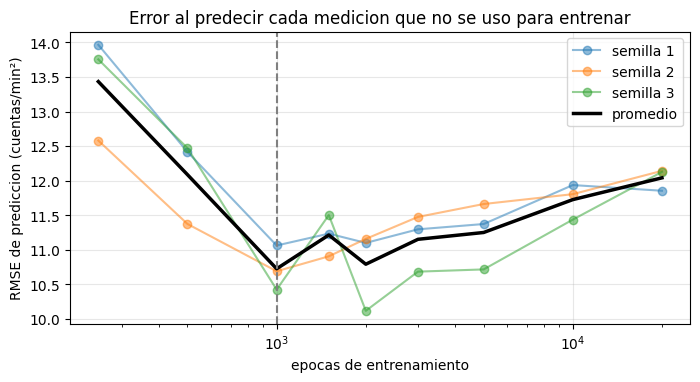

In [8]:
plt.figure(figsize=(8, 3.8))
for s in SEMILLAS_LOO:
    plt.plot(PUNTOS, [curvas_loo[s][p] for p in PUNTOS], "o-", alpha=0.5, label=f"semilla {s}")
plt.plot(PUNTOS, [media_loo[p] for p in PUNTOS], "k-", lw=2.5, label="promedio")
plt.axvline(EPOCAS, color="gray", ls="--")
plt.xscale("log"); plt.xlabel("epocas de entrenamiento"); plt.ylabel("RMSE de prediccion (cuentas/min²)")
plt.title("Error al predecir cada medicion que no se uso para entrenar"); plt.legend(); plt.show()

La curva tiene la forma que describe la figura 5.12 del capítulo. Con pocas épocas (250) la red todavía no ha aprendido la forma de la curva y el error es alto: **subentrenamiento**. El error baja hasta un mínimo alrededor de 1 000 a 2 000 épocas y después vuelve a subir lentamente, porque la red empieza a ajustar el ruido de las mediciones: **sobreentrenamiento**. Se eligen las 1 000 épocas del mínimo del promedio. La selección no es crítica: entre 1 000 y 5 000 épocas el error de predicción se mantiene entre 10.7 y 11.3 cuentas/min².

## 6. Entrenamiento del modelo final

Perdida J inicial: 0.6366   final: 0.0130
RMSE sobre los datos de entrenamiento: 7.51 cuentas/min²

 concentracion     estado  velocidad   red  residuo
          0.02   tratadas         76  65.7     10.3
          0.02   tratadas         47  65.7    -18.7
          0.06   tratadas         97 101.1     -4.1
          0.06   tratadas        107 101.1      5.9
          0.11   tratadas        123 129.2     -6.2
          0.11   tratadas        139 129.2      9.8
          0.22   tratadas        159 160.1     -1.1
          0.22   tratadas        152 160.1     -8.1
          0.56   tratadas        191 190.2      0.8
          0.56   tratadas        201 190.2     10.8
          1.10   tratadas        207 204.1      2.9
          1.10   tratadas        200 204.1     -4.1
          0.02 sin tratar         67  56.9     10.1
          0.02 sin tratar         51  56.9     -5.9
          0.06 sin tratar         84  84.6     -0.6
          0.06 sin tratar         86  84.6      1.4
          0.11 s

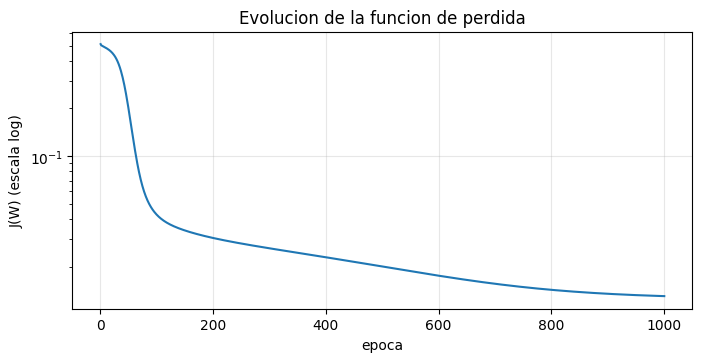

Pesos aprendidos:
W1 =
[[ 0.5888  1.4017]
 [-1.3237  0.3832]
 [ 0.0006 -0.1524]
 [ 0.4687  0.9196]]
B1^T = [-1.6387 -1.2639  0.061  -1.1757]

W2 =
[[ 1.2985 -2.6177 -0.4177  1.3933]
 [-0.3923  0.442  -0.5302  0.075 ]
 [-0.8708  0.1126 -0.5043 -0.5541]
 [ 0.4856 -0.8814 -0.1895  0.9852]]
B2^T = [-0.2986  0.5531  0.385   0.5411]

W3 =
[[ 4.3017 -0.461  -0.8037  0.8627]]
B3^T = [-1.7304]



In [9]:
SEMILLA = 1
W, B, hist = entrena(X, Yr, NN, ETA, EPOCAS, SEMILLA)
A3, _ = propaga(X, W, B)
ajuste = a_velocidad(A3.ravel())
rmse_ajuste = np.sqrt(np.mean((ajuste - tabla.velocidad.values) ** 2))
print(f"Perdida J inicial: {perdida(propaga(X, *inicializa(NN, SEMILLA))[0], Yr):.4f}   final: {hist[-1]:.4f}")
print(f"RMSE sobre los datos de entrenamiento: {rmse_ajuste:.2f} cuentas/min²\n")

tabla["red"] = ajuste.round(1)
tabla["residuo"] = (tabla.velocidad - tabla.red).round(1)
print(tabla[["concentracion", "estado", "velocidad", "red", "residuo"]].to_string(index=False))

plt.figure(figsize=(8, 3.6))
plt.semilogy(np.arange(1, EPOCAS + 1), hist)
plt.xlabel("epoca"); plt.ylabel("J(W) (escala log)"); plt.title("Evolucion de la funcion de perdida")
plt.show()

print("Pesos aprendidos:")
for k in (1, 2, 3):
    print(f"W{k} =\n{W[k].round(4)}\nB{k}^T = {B[k].ravel().round(4)}\n")

La pérdida baja de 0.64 a 0.013 en las 1 000 épocas. Sobre los propios datos de entrenamiento, la red tiene un error típico de 7.5 cuentas/min², y los residuos más grandes aparecen justamente donde las dos repeticiones difieren más: en 0.02 ppm con células tratadas las mediciones son 76 y 47, y la red responde 65.7, entre las dos. Un modelo no puede acertar a la vez dos valores distintos medidos en las mismas condiciones.

## 7. Referencias para juzgar el modelo

Que la red se ajuste bien a los datos con los que se entrenó no dice si es un buen modelo. Se compara con tres referencias independientes:

1. **El modelo físico de Michaelis-Menten**, que describe este tipo de reacción con dos parámetros por grupo de células:
$$v = \frac{V_{max}\,c}{K + c}$$
donde $V_{max}$ es la velocidad máxima, a la que se llega cuando la concentración es muy alta, y $K$ la concentración a la que se alcanza la mitad de esa velocidad. Se ajusta por mínimos cuadrados no lineales con `scipy.optimize.curve_fit`.
2. **Una neurona sin capas ocultas** con salida lineal y las mismas dos características. Es la red más simple posible y equivale a una regresión lineal.
3. **El error puro del experimento**: la desviación estándar entre las repeticiones de una misma condición. Es la variabilidad de las mediciones y ningún modelo puede predecir una medición nueva con un error menor.

In [10]:
def michaelis_menten(c, Vmax, K):
    return Vmax * c / (K + c)

def ajusta_mm(conc, vel, trat):
    return {s: curve_fit(michaelis_menten, conc[trat == s], vel[trat == s], p0=[200, 0.1])[0] for s in (0, 1)}

def predice_mm(params, conc, trat):
    return np.array([michaelis_menten(c, *params[int(s)]) for c, s in zip(conc, trat)])

c_all, v_all, t_all = tabla.concentracion.values, tabla.velocidad.values.astype(float), tabla.tratada.values
MM = ajusta_mm(c_all, v_all, t_all)
for s in (1, 0):
    print(f"Michaelis-Menten, celulas {ETIQ[s]:<10}: Vmax = {MM[s][0]:6.1f} cuentas/min²   K = {MM[s][1]:.4f} ppm")
rmse_mm = np.sqrt(np.mean((predice_mm(MM, c_all, t_all) - v_all) ** 2))
print(f"RMSE de Michaelis-Menten sobre los datos: {rmse_mm:.2f}")

# Error puro: la variacion entre las dos repeticiones de una misma condicion
g = tabla.groupby(["estado", "concentracion"]).velocidad
dif = g.apply(lambda v: np.sum((v - v.mean()) ** 2)).sum()
gl = (g.count() - 1).sum()
error_puro = np.sqrt(dif / gl)
print(f"\nDesviacion estandar entre repeticiones (error puro): {error_puro:.2f} cuentas/min² ({gl} grados de libertad)")
print(f"RMSE minimo que puede lograr cualquier modelo sobre estos 23 datos: {np.sqrt(dif / len(tabla)):.2f}")

Michaelis-Menten, celulas tratadas  : Vmax =  212.7 cuentas/min²   K = 0.0641 ppm
Michaelis-Menten, celulas sin tratar: Vmax =  160.3 cuentas/min²   K = 0.0477 ppm
RMSE de Michaelis-Menten sobre los datos: 9.45

Desviacion estandar entre repeticiones (error puro): 9.97 cuentas/min² (11 grados de libertad)
RMSE minimo que puede lograr cualquier modelo sobre estos 23 datos: 6.90


Los parámetros de Michaelis-Menten coinciden con los que reportan Bates y Watts (1988) para este conjunto: $V_{max} \approx 213$ y $K \approx 0.064$ para las células tratadas. La desviación entre repeticiones es de casi 10 cuentas/min², y el menor error que puede tener cualquier modelo sobre estos 23 datos es 6.9, el que se obtiene respondiendo el promedio de cada par de repeticiones. La red, con 7.5, está cerca de ese límite; el modelo físico, con 9.5, se aleja más porque solo tiene cuatro parámetros.

Para comparar la capacidad de **predicción** se aplica a los cuatro modelos la misma validación cruzada dejando uno fuera:

In [11]:
def loo_general(ajustar, predecir):
    m = len(v_all); pred = np.zeros(m)
    for i in range(m):
        k = np.arange(m) != i
        modelo = ajustar(k)
        pred[i] = predecir(modelo, i)
    return np.sqrt(np.mean((pred - v_all) ** 2)), pred

# a) Red con dos capas ocultas (la del ejercicio)
def ajusta_red(k):
    return entrena(X[:, k], Yr[:, k], NN, ETA, EPOCAS, SEMILLA)[:2]
rmse_red, pred_red = loo_general(ajusta_red, lambda m_, i: a_velocidad(propaga(X[:, [i]], *m_)[0][0, 0]))

# b) Neurona sin capas ocultas: salida lineal de las mismas dos caracteristicas (regresion lineal)
def ajusta_lineal(k):
    A = np.vstack([np.ones(k.sum()), X[:, k]]).T
    return np.linalg.lstsq(A, v_all[k], rcond=None)[0]
rmse_lin, _ = loo_general(ajusta_lineal, lambda w, i: w @ np.r_[1, X[:, i]])

# c) Modelo fisico de Michaelis-Menten, 2 parametros por grupo
rmse_mm_loo, _ = loo_general(lambda k: ajusta_mm(c_all[k], v_all[k], t_all[k]),
                             lambda p, i: predice_mm(p, c_all[[i]], t_all[[i]])[0])

# d) Promedio de la tabla (no usa ninguna caracteristica)
rmse_media, _ = loo_general(lambda k: v_all[k].mean(), lambda mu, i: mu)

print(f"{'Modelo':<52}{'Parametros':>11}{'RMSE LOO':>10}")
print("-" * 73)
for nombre, npar, r in (("Promedio de todas las mediciones", 1, rmse_media),
                        ("Neurona lineal sin capas ocultas (log c, estado)", 3, rmse_lin),
                        ("Michaelis-Menten (modelo fisico)", 4, rmse_mm_loo),
                        ("Red 2-4-4-1 con dos capas ocultas", n_param, rmse_red)):
    print(f"{nombre:<52}{npar:>11}{r:>10.2f}")
print(f"{'Error puro entre repeticiones (limite inferior)':<52}{'':>11}{error_puro:>10.2f}")

Modelo                                               Parametros  RMSE LOO
-------------------------------------------------------------------------
Promedio de todas las mediciones                              1     48.58
Neurona lineal sin capas ocultas (log c, estado)              3     12.64
Michaelis-Menten (modelo fisico)                              4     11.26
Red 2-4-4-1 con dos capas ocultas                            37     11.06
Error puro entre repeticiones (limite inferior)                      9.97


La tabla permite sacar tres conclusiones:

- **Las capas ocultas son necesarias.** La neurona sin capas ocultas tiene un error de predicción de 12.6: aunque la concentración entra en escala logarítmica, la relación entre la velocidad y la concentración no es una recta. La red con dos capas ocultas lo reduce a 11.1.
- **La red predice tan bien como el modelo físico** (11.1 frente a 11.3), sin que se le haya indicado la forma de la ecuación de Michaelis-Menten: la aprendió de los datos.
- **Las dos están cerca del límite del experimento.** El error puro es de 10.0, así que al predecir una medición nueva ningún modelo puede bajar mucho de ese valor. La diferencia de 0.2 entre la red y el modelo físico no es significativa con 23 datos, y el valor de la red es levemente optimista porque la misma validación cruzada se usó para escoger el número de épocas.

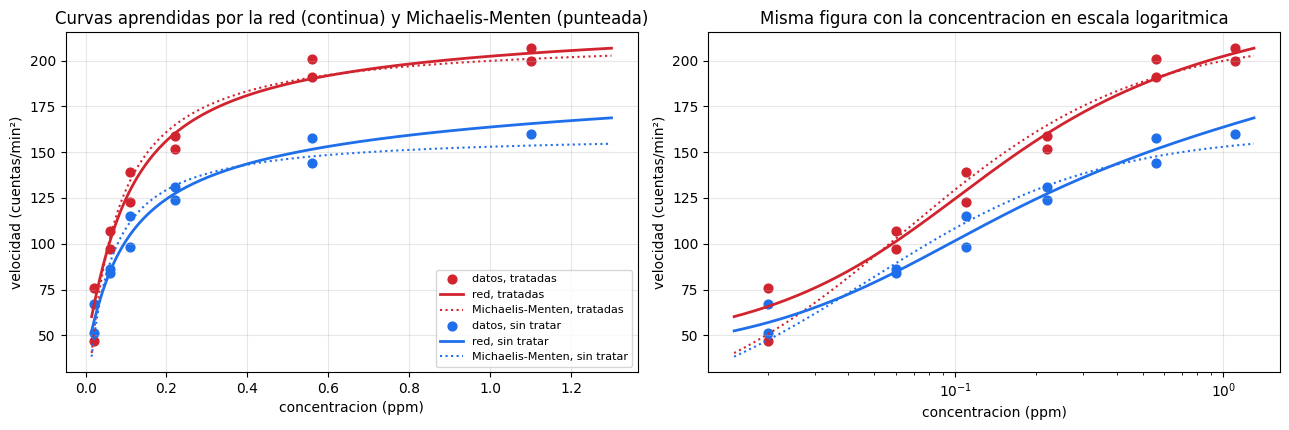

In [12]:
malla = np.logspace(np.log10(0.015), np.log10(1.3), 200)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for j, escala in enumerate(("linear", "log")):
    for s in (1, 0):
        d = tabla[tabla.tratada == s]
        ax[j].scatter(d.concentracion, d.velocidad, color=COLOR[s], s=40, label=f"datos, {ETIQ[s]}")
        ax[j].plot(malla, a_velocidad(propaga(caracteristicas(malla, s), W, B)[0].ravel()),
                   color=COLOR[s], lw=2, label=f"red, {ETIQ[s]}")
        ax[j].plot(malla, michaelis_menten(malla, *MM[s]), color=COLOR[s], ls=":", lw=1.5,
                   label=f"Michaelis-Menten, {ETIQ[s]}")
    ax[j].set_xscale(escala); ax[j].set_xlabel("concentracion (ppm)"); ax[j].set_ylabel("velocidad (cuentas/min²)")
ax[0].legend(fontsize=8)
ax[0].set_title("Curvas aprendidas por la red (continua) y Michaelis-Menten (punteada)")
ax[1].set_title("Misma figura con la concentracion en escala logaritmica")
plt.tight_layout(); plt.show()

Dentro del rango medido, las curvas de la red (continuas) y las de Michaelis-Menten (punteadas) prácticamente se superponen, para los dos grupos de células. La red reproduce la saturación y la separación entre tratadas y no tratadas, que aumenta con la concentración. Las diferencias aparecen en los extremos del rango: en las células sin tratar a concentraciones altas, donde solo hay tres mediciones (144, 158 y 160) para fijar la forma de la curva, y en la concentración más baja, donde las repeticiones están muy dispersas (47 y 76) y la red se queda en el promedio mientras que el modelo físico baja hacia cero, como exige la ecuación de Michaelis-Menten.

### 7.1 Robustez frente a la inicialización

In [13]:
SEMILLAS = range(1, 11)
filas = []
for s in SEMILLAS:
    Ws, Bs, hs = entrena(X, Yr, NN, ETA, EPOCAS, s)
    aj = a_velocidad(propaga(X, Ws, Bs)[0].ravel())
    p = a_velocidad(propaga(caracteristicas([0.3, 0.3], [1, 0]), Ws, Bs)[0].ravel())
    filas.append((s, np.sqrt(np.mean((aj - v_all) ** 2)), p[0], p[1]))
rob = pd.DataFrame(filas, columns=["semilla", "RMSE ajuste", "pred. 0.30 ppm tratadas", "pred. 0.30 ppm sin tratar"])
print(rob.round(2).to_string(index=False))
print("\nPromedio y desviacion entre semillas:")
print(rob.drop(columns="semilla").agg(["mean", "std"]).round(2).to_string())

 semilla  RMSE ajuste  pred. 0.30 ppm tratadas  pred. 0.30 ppm sin tratar
       1         7.51                   171.75                     136.14
       2         7.43                   171.29                     135.81
       3         7.40                   173.80                     137.18
       4         7.98                   170.69                     136.47
       5         7.35                   171.68                     136.26
       6         8.39                   168.59                     136.75
       7         7.34                   172.67                     135.99
       8         8.14                   170.10                     136.38
       9         7.63                   170.68                     135.64
      10         7.46                   173.53                     135.32

Promedio y desviacion entre semillas:
      RMSE ajuste  pred. 0.30 ppm tratadas  pred. 0.30 ppm sin tratar
mean         7.66                   171.48                     136.19
std    

Con diez inicializaciones aleatorias distintas, el error de ajuste va de 7.3 a 8.4 y la predicción a 0.30 ppm para células tratadas queda entre 168.6 y 173.8 cuentas/min², con una desviación de 1.6 entre semillas, muy por debajo del error puro de las mediciones. El resultado no depende de haber escogido una semilla favorable.

## 8. Predicción con datos nuevos

Esta es la parte final del enunciado: darle datos al modelo para hacer una predicción. Se piden velocidades para siete concentraciones que **no se midieron** en el experimento, entre 0.04 y 1.00 ppm, para los dos grupos de células. Para cada una se muestra también la predicción del modelo físico, que sirve como referencia.

In [14]:
nuevos = pd.DataFrame({
    "concentracion": [0.04, 0.08, 0.15, 0.30, 0.40, 0.80, 1.00] * 2,
    "tratada":       [1] * 7 + [0] * 7,
})
nuevos["estado"] = nuevos.tratada.map(ETIQ)
nuevos["red"] = a_velocidad(propaga(caracteristicas(nuevos.concentracion, nuevos.tratada), W, B)[0].ravel())
nuevos["Michaelis-Menten"] = predice_mm(MM, nuevos.concentracion.values, nuevos.tratada.values)
nuevos["diferencia"] = nuevos["red"] - nuevos["Michaelis-Menten"]
print("Predicciones de la red para concentraciones que no estan en la tabla:\n")
print(nuevos[["concentracion", "estado", "red", "Michaelis-Menten", "diferencia"]].to_string(
    index=False, formatters={"concentracion": "{:.2f}".format, "red": "{:.1f}".format,
                             "Michaelis-Menten": "{:.1f}".format, "diferencia": "{:+.1f}".format}))

piv = nuevos.pivot(index="concentracion", columns="estado", values="red")
print("\nEfecto del tratamiento segun la red (tratadas - sin tratar):")
for c, fila in piv.iterrows():
    print(f"   {c:>5.2f} ppm: {fila['tratadas'] - fila['sin tratar']:>6.1f} cuentas/min²"
          f"  ({(fila['tratadas'] / fila['sin tratar'] - 1):+.0%})")

Predicciones de la red para concentraciones que no estan en la tabla:

concentracion     estado   red Michaelis-Menten diferencia
         0.04   tratadas  85.2             81.7       +3.5
         0.08   tratadas 114.1            118.1       -4.0
         0.15   tratadas 143.7            149.0       -5.3
         0.30   tratadas 171.7            175.2       -3.5
         0.40   tratadas 181.0            183.3       -2.3
         0.80   tratadas 198.1            196.9       +1.2
         1.00   tratadas 202.4            199.9       +2.5
         0.04 sin tratar  72.5             73.1       -0.6
         0.08 sin tratar  94.1            100.4       -6.3
         0.15 sin tratar 115.3            121.6       -6.3
         0.30 sin tratar 136.1            138.3       -2.1
         0.40 sin tratar 143.6            143.2       +0.4
         0.80 sin tratar 159.3            151.3       +8.0
         1.00 sin tratar 163.7            153.0      +10.7

Efecto del tratamiento segun la red (tratad

Las predicciones de la red y las del modelo físico difieren en menos de 7 cuentas/min² en 12 de los 14 casos, por debajo del error puro de las mediciones. Las dos diferencias mayores, de 8 y 11, están en las células sin tratar a 0.80 y 1.00 ppm: la red sigue de cerca la medición de 160 a 1.10 ppm, mientras que Michaelis-Menten impone una saturación en 160 que la aplana antes.

La red también permite responder una pregunta experimental: **cuánto aumenta la velocidad el tratamiento con puromicina**. Según el modelo, el aumento es de 13 cuentas/min² (18 %) a 0.04 ppm y crece hasta unas 39 cuentas/min² a partir de 0.8 ppm; en términos relativos se estabiliza entre 24 y 26 % desde 0.15 ppm. Es decir, el tratamiento eleva sobre todo la velocidad máxima de la reacción, lo que concuerda con la diferencia entre los $V_{max}$ del modelo físico (213 frente a 160).

### 8.1 Predicción fuera del rango medido

In [15]:
fuera = pd.DataFrame({"concentracion": [1.10, 2.0, 5.0, 20.0, 1.10, 2.0, 5.0, 20.0], "tratada": [1] * 4 + [0] * 4})
fuera["estado"] = fuera.tratada.map(ETIQ)
fuera["red"] = a_velocidad(propaga(caracteristicas(fuera.concentracion, fuera.tratada), W, B)[0].ravel())
fuera["Michaelis-Menten"] = predice_mm(MM, fuera.concentracion.values, fuera.tratada.values)
fuera["Vmax del modelo fisico"] = [MM[s][0] for s in fuera.tratada]
print(fuera[["concentracion", "estado", "red", "Michaelis-Menten", "Vmax del modelo fisico"]].to_string(
    index=False, formatters={"concentracion": "{:.2f}".format, "red": "{:.1f}".format,
                             "Michaelis-Menten": "{:.1f}".format, "Vmax del modelo fisico": "{:.1f}".format}))

# Cuando la concentracion crece sin limite, las sigmoides de la capa 1 se saturan en 0 o en 1
# y la salida de la red se vuelve constante.
print()
grande = caracteristicas([1e6, 1e6], [1, 0])
lim = a_velocidad(propaga(grande, W, B)[0].ravel())
print(f"Valor al que tiende la red cuando la concentracion crece sin limite: tratadas {lim[0]:.1f}, sin tratar {lim[1]:.1f}")

concentracion     estado   red Michaelis-Menten Vmax del modelo fisico
         1.10   tratadas 204.1            201.0                  212.7
         2.00   tratadas 212.8            206.1                  212.7
         5.00   tratadas 222.1            210.0                  212.7
        20.00   tratadas 230.7            212.0                  212.7
         1.10 sin tratar 165.6            153.6                  160.3
         2.00 sin tratar 176.4            156.5                  160.3
         5.00 sin tratar 191.2            158.8                  160.3
        20.00 sin tratar 209.3            159.9                  160.3

Valor al que tiende la red cuando la concentracion crece sin limite: tratadas 242.3, sin tratar 241.9


Fuera del rango medido la situación cambia por completo. Según el modelo físico, la velocidad no puede superar $V_{max}$: 213 para las células tratadas y 160 para las no tratadas. La red, en cambio, sigue subiendo, 209 para las no tratadas a 20 ppm, y tiende a unos 242 para los dos grupos, con lo que la diferencia entre tratadas y no tratadas desaparece. Las dos cosas contradicen lo que se sabe de la reacción.

La razón es que la red **no conoce la ley física**: solo aprendió una curva que pasa cerca de los puntos entre 0.02 y 1.10 ppm. Más allá, su salida depende de cómo se saturen las sigmoides de las capas ocultas, algo que los datos no controlan. Una red neuronal **interpola** bien, pero sus predicciones fuera del rango de los datos de entrenamiento no son confiables.

## 9. Verificación con TensorFlow

Como comprobación final se construye la misma red 2‑4‑4‑1 con TensorFlow/Keras, se le cargan **los mismos pesos iniciales** de la versión en NumPy y se entrena con descenso del gradiente simple (`SGD`) usando los 23 ejemplos en cada paso. Keras usa la pérdida `mse` $= \frac{1}{m}\sum e^2$, que es el doble de $J$, así que su gradiente también es el doble; para que los dos entrenamientos sean idénticos se usa una tasa de aprendizaje de $\eta/2$. Si la implementación de la sección 3 es correcta, los dos entrenamientos deben recorrer exactamente el mismo camino.

In [16]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
tf.keras.utils.set_random_seed(0)

red_tf = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    tf.keras.layers.Dense(4, activation="sigmoid", name="oculta_1"),
    tf.keras.layers.Dense(4, activation="sigmoid", name="oculta_2"),
    tf.keras.layers.Dense(1, activation="linear", name="salida"),
], name="red_2_4_4_1")
W0, B0 = inicializa(NN, SEMILLA)                       # los mismos pesos iniciales de la version NumPy
red_tf.set_weights([p for k in (1, 2, 3) for p in (W0[k].T, B0[k].ravel())])
red_tf.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=ETA / 2), loss="mse")
red_tf.summary()
h_tf = red_tf.fit(X.T.astype("float32"), Yr.T.astype("float32"), epochs=EPOCAS, batch_size=X.shape[1],
                  shuffle=False, verbose=0)

pred_tf = a_velocidad(red_tf.predict(X.T, verbose=0).ravel())
print(f"\nPerdida final: NumPy J = {hist[-1]:.6f}   Keras MSE/2 = {h_tf.history['loss'][-1] / 2:.6f}")
print(f"Diferencia maxima entre las predicciones de NumPy y de Keras: {np.abs(pred_tf - ajuste).max():.4f} cuentas/min²")
Wtf = red_tf.get_weights()
print(f"Diferencia maxima entre los pesos finales: {max(np.abs(Wtf[2*(k-1)] - W[k].T).max() for k in (1, 2, 3)):.2e}")

I0000 00:00:1790554260.837142    8976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1790554262.461741    8976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Model: "red_2_4_4_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)


Perdida final: NumPy J = 0.013042   Keras MSE/2 = 0.013045
Diferencia maxima entre las predicciones de NumPy y de Keras: 0.0001 cuentas/min²
Diferencia maxima entre los pesos finales: 3.28e-06


Después de 1 000 épocas, los pesos de las dos versiones difieren en menos de $10^{-5}$ y las predicciones en una diez milésima de cuenta/min², diferencias que se explican porque TensorFlow trabaja en precisión simple. La red programada a mano con las ecuaciones del capítulo y la red de Keras son la misma red.

## 10. Conclusiones

1. **Se construyó un modelo de un experimento real con una red de dos capas ocultas.** A partir de la tabla de 23 mediciones de Treloar (1974), la red 2‑4‑4‑1 aprendió a predecir la velocidad de la reacción en función de la concentración del sustrato y del tratamiento de las células, con un error de predicción de 11.1 cuentas/min² sobre datos que no vio.
2. **La red aprendió la ley del experimento sin conocerla.** Su error de predicción es igual al del modelo de Michaelis-Menten (11.3) y ambos están cerca del error puro de las mediciones (10.0), el mínimo que se puede alcanzar. Dentro del rango medido las curvas de la red y del modelo físico prácticamente coinciden.
3. **Las capas ocultas son las que permiten representar la no linealidad.** Una neurona sin capas ocultas, con las mismas características, tiene un error de 12.6.
4. **Con pocos datos, el número de épocas es decisivo.** La red tiene más parámetros (37) que datos (23). Con validación cruzada se identificaron el subentrenamiento y el sobreentrenamiento de la figura 5.12 y se escogió detener el entrenamiento en 1 000 épocas.
5. **La predicción es confiable dentro del rango de los datos y no fuera de él.** Para concentraciones nuevas entre 0.04 y 1.00 ppm, la red y el modelo físico coinciden y estiman que el tratamiento aumenta la velocidad hasta en un 26 %. Por encima de 1.10 ppm la red viola la saturación que exige la física de la reacción. Un modelo físico extrapola mejor porque su forma viene de la teoría; la red solo sabe lo que hay en los datos.
6. **La implementación es correcta.** La retropropagación de las ecuaciones de la sección 5.5 coincide con el gradiente numérico (error relativo de $10^{-8}$) y reproduce paso a paso el entrenamiento de la misma red en TensorFlow.